# Data Challenge Project Work CO2

## 1. Introduction

###### Ka Men Ho, Luana Aido da Silva, Michèle Pfister

The project explores the performance of machine learning (ML) algorithms for the prediction and diagnosis of heart disease. As heart disease remains one of the leading causes of mortality worldwide, in this data challenge project we aim to understand, how early detection strategies can be improved using these tools, which have the potential to enhance patient outcomes and reduce disease-related mortality (Alshenawy, 2024).

The underlying biological mechanisms of heart attacks and strokes involve obstruction of blood flow to the heart or brain due to arterial plaque accumulation or thrombus formation. A major clinical challenge is that symptoms of heart disease are often nonspecific, overlapping with those of other conditions or being misattributed to normal aging, which complicates preventive and accurate diagnosis (Quah et al., 2014).

Machine learning has become an increasingly important tool in healthcare, enhancing clinical decision-making in disease prediction and diagnosis. Traditional approaches relied largely on practitioners’ interpretation of a patient’s medical history, reported symptoms, and physical examination findings (Karthick et al., 2022).

The dataset used in this project was obtained from the University of California Irvine (UCI) Machine Learning Repository and is widely employed for heart disease prediction tasks. Patient outcomes were determined using cardiac catheterization, considered the clinical gold standard, where individuals exhibiting more than 50% narrowing of a coronary artery were classified as having heart disease.
The dataset comprises 270 patient records and includes 13 independent predictive variables. Detailed descriptions of these attributes are provided in the UCI repository documentation (University of California, Irvine, n.d.)

An updated version of the heart disease dataset includes 303 consecutive patients referred for coronary angiography at the Cleveland Clinic in Cleveland, Ohio, between May 1981 and September 1984. This cohort was used to develop the Cleveland algorithm, a computerized diagnostic model whose regression coefficients were later validated using independent patient populations from Budapest, Long Beach, and Switzerland.
The Cleveland cohort had a mean age of 54 years, consisted of 68% men, and showed a disease prevalence of 46%. The model was derived from 13 clinical and test-related variables, with age, sex, chest pain type, and systolic blood pressure identified as key predictors. Chest pain was categorized as typical anginal, atypical anginal, nonanginal, or asymptomatic, and inclusion of age, sex, and chest pain type was required for clinically relevant disease probability estimation.

Because complete joint distributions of clinical variables were rarely available, the original model assumed independence among predictors. However, previous research has shown that ignoring interdependencies between symptoms can result in overconfident predictions and inaccurate disease probability estimates (Detrano et al., 1989). 

To mitigate the overconfidence that can arise from assuming independence among clinical variables, the study of Kathleen employs an ensemble learning approach using the Adaptive Boosting (AdaBoost) algorithm. AdaBoost is a meta-learning method that combines multiple weak classifiers into a single, more robust predictive model. Through 100 iterative boosting rounds, the algorithm adaptively increases the weight of observations that were misclassified in previous iterations, encouraging subsequent classifiers to focus on complex or interacting symptom patterns that are difficult to capture with a single model. The final prediction is produced via a weighted majority vote of all component classifiers, resulting in a classifier that is less prone to overconfident assumptions and better aligned with the true diagnostic outcome (Kathleen et al., 2016).

Alshenawy (2024) evaluated several machine learning algorithms, both individually and in ensemble settings, to identify reliable approaches for heart disease diagnosis. The models analyzed included Support Vector Machines, Random Forest, Decision Trees, Naïve Bayes, and Logistic Regression as a baseline. The data were divided into training (189 observations) and testing (81 observations) sets, and model performance was assessed using multiple metrics, including accuracy, sensitivity, specificity, and AUC.

Among the individual models, Random Forest achieved the highest overall performance, while ensemble approaches using bagging produced comparable but not superior results. Building on this framework, the data challenge project work CO2 applies a similar comparative evaluation of multiple machine learning models, with particular emphasis on ensemble methods, to assess their effectiveness in heart disease prediction.


### Table of contents

- 1. Introduction

- 2. Exploratory data analysis
- 2. 1 Importing Libraries and load the data
- 3. Preprocessing
- 3. 1 Cleaning the data 
- 3. 2 Handling missing values
- 3. 3 Converting text labels to numbers (feature encoding)
- 4. Modelling
- 4. 1 symple base-line model
- 4. 2 two sophisticated model approaches
- 4. 3 Experiment and testing the model
- 5. Results
- 6. Discussion


## 2. Exploratory data analysis

Analyse your data. Visualise and explain the data features you deem to be relevant for
the project.

### 2.1 Importing Libraries and load data

In [1]:
# Importing the libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import * 
import warnings
warnings.filterwarnings("ignore")


heart_data = pd.read_csv("Heart_Disease_Prediction.csv")

heart_data.head()


,index,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


### 2.2 Data Dictionary
The data dictionary provides a structured overview of all features used in the analysis, including their data types and meaning. The categorical features documentation details the encoding and meaning of all non-numerical variables.

1. **age:** age in years (Numeric)
2. **sex:** biological gender of the patient (Categorical)
3. **chest pain type:** the type of chest pain experienced by the patient (Categorical)
4. **BP:** blood pressure level of the patient (Numeric)
5. **cholesterol:** cholesterol level of the patient (Numeric)
6. **FBS over 120:** fasting blood sugar test results over 120 mg/dl (Categorical)
7. **EKG results:** electrocardiogram results of the patient (Categorical)
8. **Max HR:** maximum heart rate levels achieved during exercise testing (Numeric)
9. **Excercise angina:** angina experienced during exercise testing ( Categorical)
10. **ST depression:** ST depression on an Electrocardiogram (Numeric)
11. **Slope of ST:** The slope of ST segment electrodiagram readings (Categorical)
12. **Number of vessles fluro:** amount of vessels seen in Fluoroscopy images ( Categorical)
13. **Thallium:** Thallium Stress test findings (Categorical)
14. **Heart Disease:** Whether or not the patient has been diagnosed with Heart Disease (Categorical)

### 2.3 Categorial features documentation:
**1. Sex:**

    0 = female 
    
    1 = male

**2. chest pain type:** 

    1 = typical angina

    2 = atypical angina

    3 = non-anginal pain

    4 = asymptomatic

**3. FBS over 120:**

    0 = no

    1 = yes

**4. EKG results:**

    0 = normal

    1 = having ST-T wave abnormality

    2 = showing probable or definite left ventricular hyperthrophy

**5. Excercise induced angina:**

    0 = no

    1 = yes

**6. Slope of ST:**

    1 = upslopong

    2 = flat

    3 = downsloping

**7. Number of vessles fluro:**

    Range of values from 1 to 3

**8. Thalium:**

    3 = normal

    6 = fixed

    7 = reversable defect

*source: https://archive.ics.uci.edu/dataset/45/heart+disease*


In [2]:
heart_data.shape
heart_data.dtypes
heart_data.isna().sum()
heart_data.isnull().sum()
heart_data.duplicated().sum()
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   index                    270 non-null    int64  
 1   Age                      270 non-null    int64  
 2   Sex                      270 non-null    int64  
 3   Chest pain type          270 non-null    int64  
 4   BP                       270 non-null    int64  
 5   Cholesterol              270 non-null    int64  
 6   FBS over 120             270 non-null    int64  
 7   EKG results              270 non-null    int64  
 8   Max HR                   270 non-null    int64  
 9   Exercise angina          270 non-null    int64  
 10  ST depression            270 non-null    float64
 11  Slope of ST              270 non-null    int64  
 12  Number of vessels fluro  270 non-null    int64  
 13  Thallium                 270 non-null    int64  
 14  Heart Disease            2

This dataset contains vital insight of 270 patients. Each patient is identified by 13 indipendent varibles, which can be seen as 13 different featurest for further analysis. There are no null or nan values found in the dataset. There is also no duplicates in the values. As the goal is to predict if someone gets a heart disease, the feature heart disease is our target variable, which is categorical, so it needs to be encoded.

In [3]:
heart_data.describe().T.round(2)
#.T makes that the features are written down as columns
# The values where rounded to two decimal values after point

,count,mean,std,min,25%,50%,75%,max
index,270.0,134.50,78.09,0.0,67.25,134.5,201.75,269.0
Age,270.0,54.43,9.11,29.0,48.00,55.0,61.00,77.0
Sex,270.0,0.68,0.47,0.0,0.00,1.0,1.00,1.0
Chest pain type,270.0,3.17,0.95,1.0,3.00,3.0,4.00,4.0
BP,270.0,131.34,17.86,94.0,120.00,130.0,140.00,200.0
Cholesterol,270.0,249.66,51.69,126.0,213.00,245.0,280.00,564.0
FBS over 120,270.0,0.15,0.36,0.0,0.00,0.0,0.00,1.0
EKG results,270.0,1.02,1.00,0.0,0.00,2.0,2.00,2.0
Max HR,270.0,149.68,23.17,71.0,133.00,153.5,166.00,202.0
Exercise angina,270.0,0.33,0.47,0.0,0.00,0.0,1.00,1.0


The descripitve statistics indicate resaonable distributions across numerical features, with age and cardiovascular measurements showing moderate variance and no extrem irregularities.

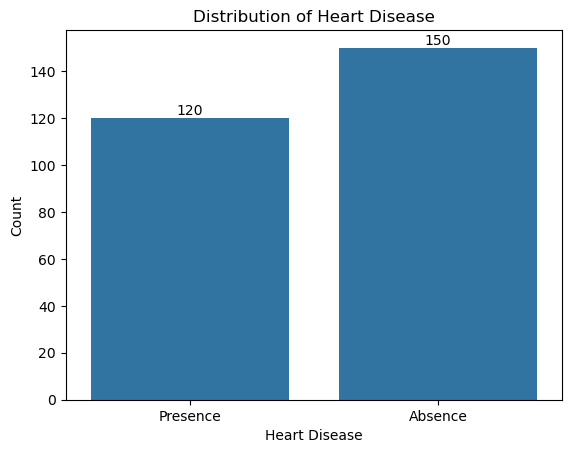

In [4]:
#countplot for the presence or absence of heart disease
disease_plot = sns.countplot(x="Heart Disease", data=heart_data)


for container in disease_plot.containers:
    disease_plot.bar_label(container)

plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.title("Distribution of Heart Disease")
plt.show()

The target variable shows a relatively balanced class distribution, with fewer ases of heart diseases compared to non-diseases cases.

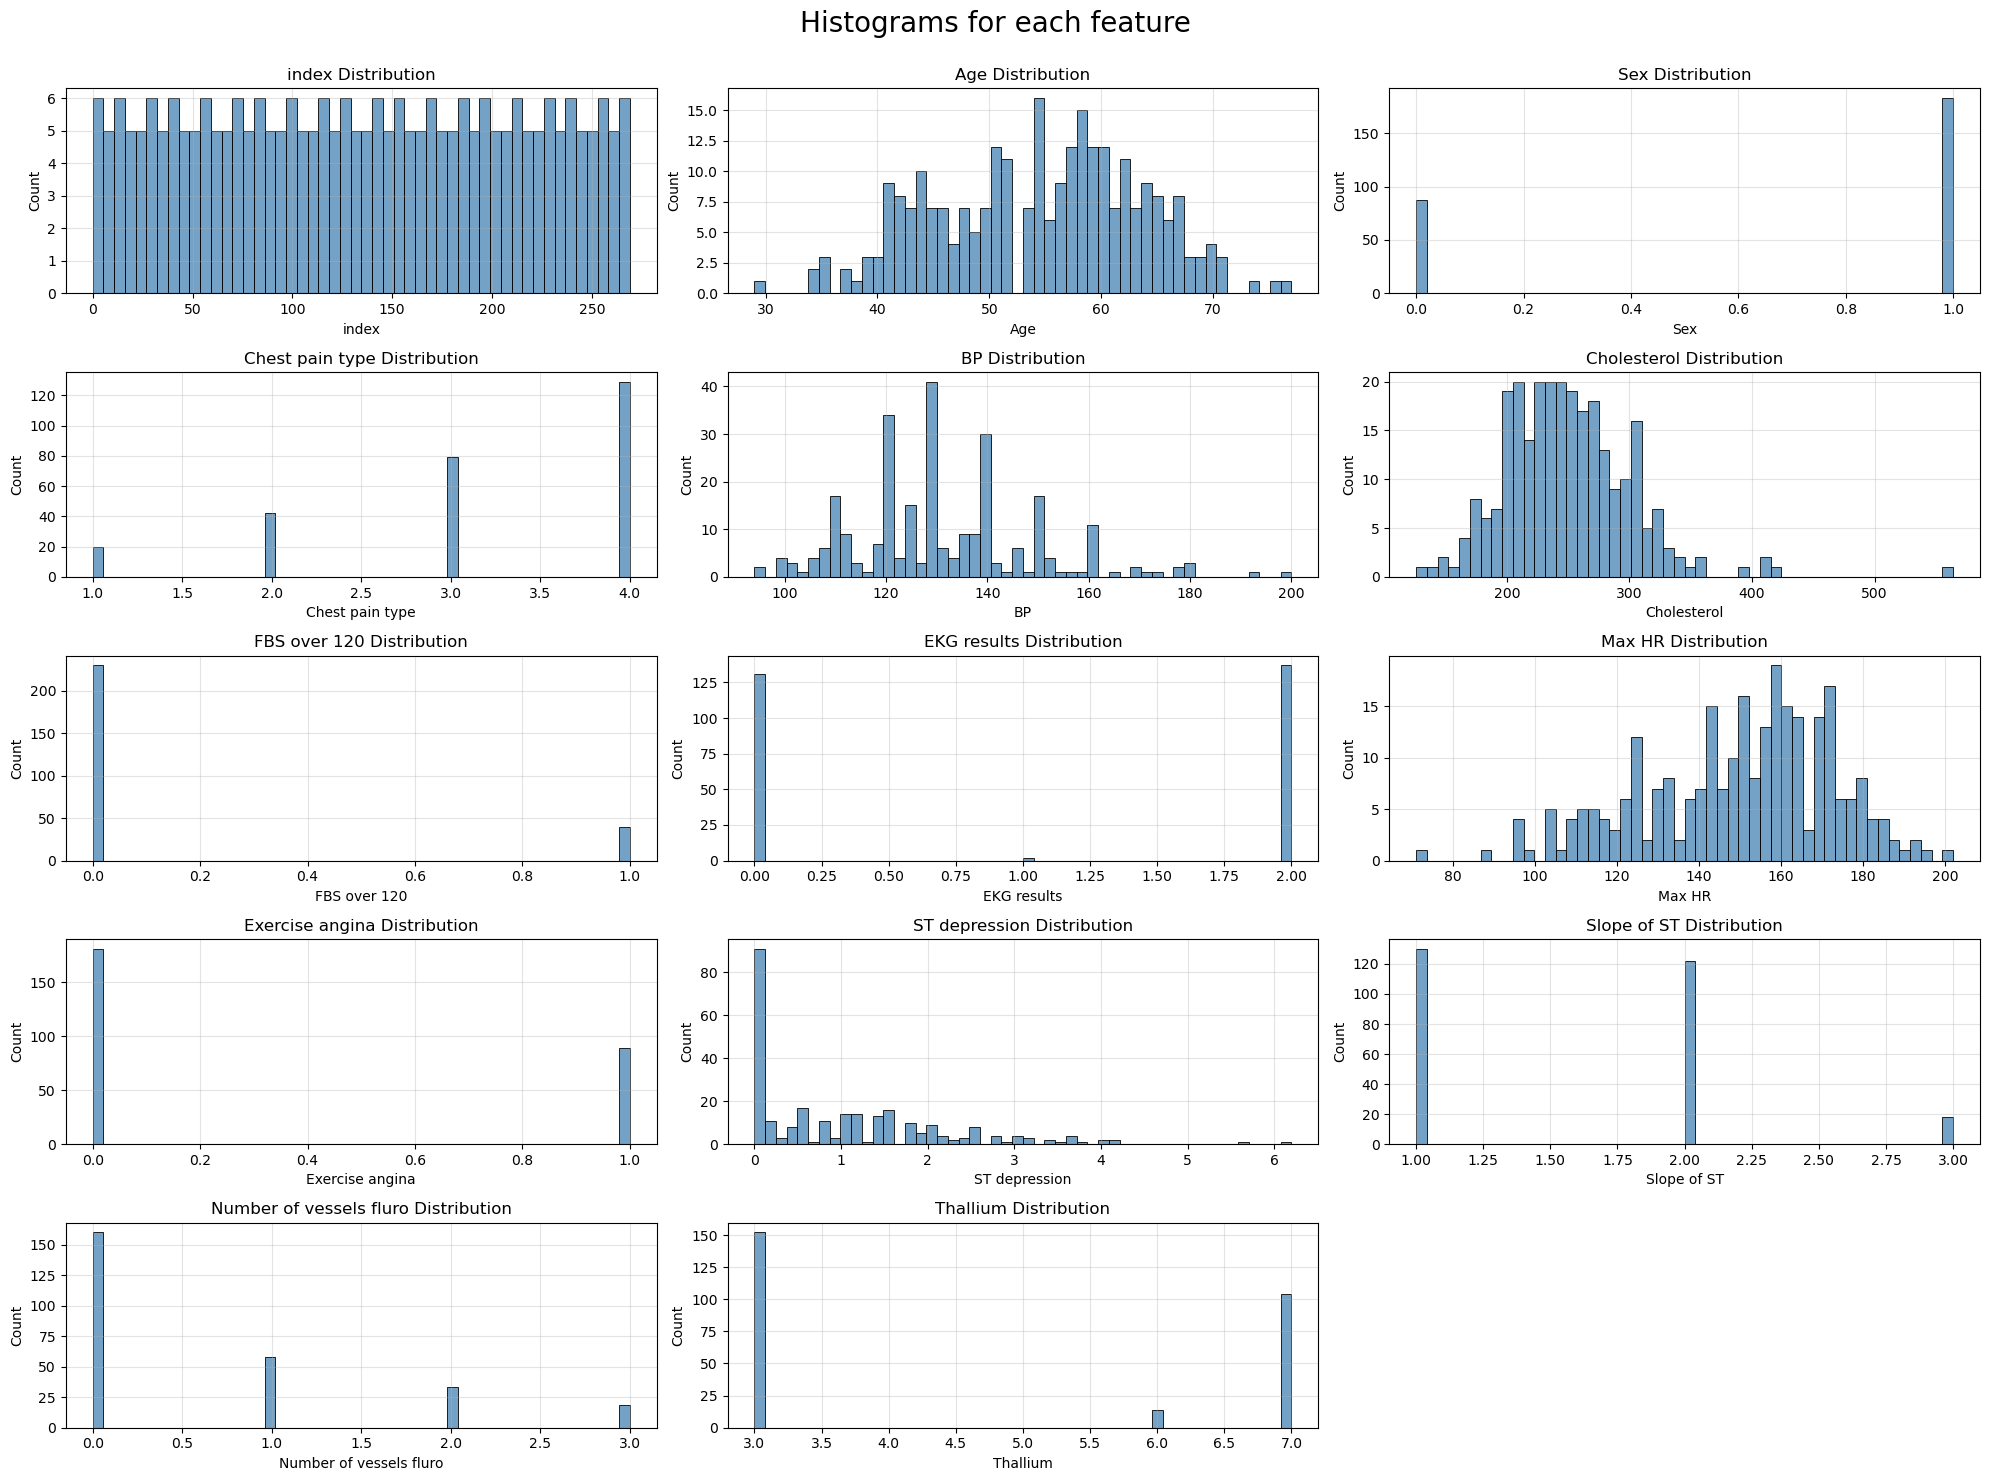

In [5]:
#Distribution of all the varibles

#Creates a new dataframe with all the features except the target feature
data = heart_data.loc[:, ~heart_data.columns.isin(["Heart Disease"])]

num_vars =  len(data.columns)
num_rows = (num_vars // 2) + (num_vars % 2)
num_cols = 3

#Grid of subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(20, 20))

#F 2D array into a 1D array
axes = axes.flatten()

for i, col in enumerate(data.columns):
    sns.histplot(data[col], bins=50, ax=axes[i], color="steelblue")
    axes[i].set_title(f"{col} Distribution")
    axes[i].grid(alpha=0.35)

for j in range(num_vars, num_rows * num_cols):
    fig.delaxes(axes[j])

plt.suptitle("Histograms for each feature", fontsize=20, y= 1)
plt.tight_layout()
plt.show()


The figure presents histograms for all features in the dataset, illustrating their individual distributions. Numerical variables such as age, blood pressure, cholesterol, maximum heart rate, and ST depression show varying degrees of spread and skewness, while categorical features appear as discrete peaks reflecting their encoded class values. Several variables, including FBS over 120, exercise angina, and number of vessels observed under fluoroscopy, exhibit highly imbalanced distributions, which may influence feature importance and model learning.

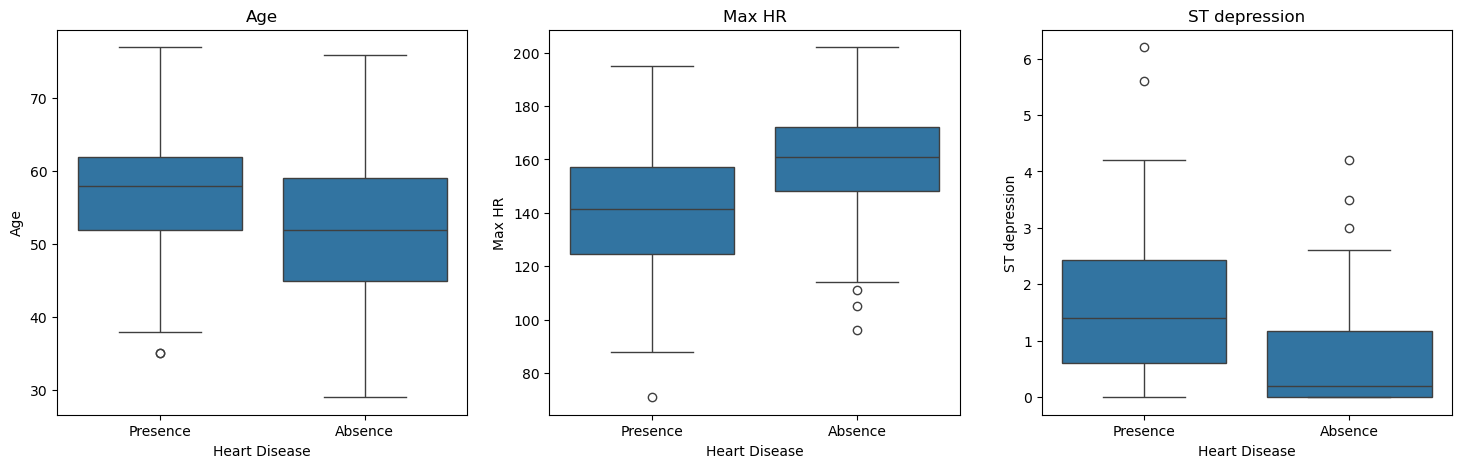

In [6]:
#boxplot numerical variables - important in literature
features = ["Age", "Max HR", "ST depression"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, feature in zip(axes, features):
    sns.boxplot(
        x="Heart Disease",
        y=feature,
        data=heart_data,
        ax=ax
    )
    ax.set_title(feature)

The boxplots compare key numerical features across patients with and without heart disease. Patients with heart disease tend to be older on average, exhibit lower maximum heart rates, and show higher ST depression values, indicating clear distributional differences between the two groups.

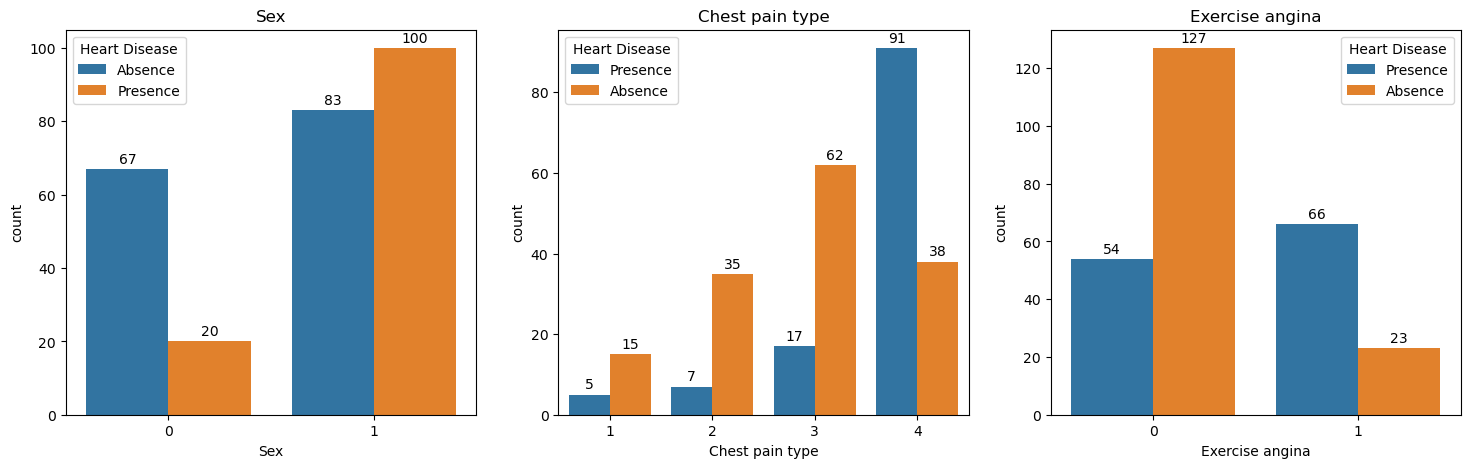

In [7]:
cat_features = ["Sex", "Chest pain type", "Exercise angina"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, cat_features):
    sns.countplot(
        x=feature,
        hue="Heart Disease",
        data=heart_data,
        ax=ax)
    
    for container in ax.containers:
        ax.bar_label(container, padding=2)

    ax.set_title(feature)

The categorical feature analysis reveals clear differences between patients with and without heart disease. Male patients are more frequently affected than female patients, while certain chest pain types are strongly associated with the presence of heart disease. Additionally, exercise-induced angina occurs more often among patients diagnosed with heart disease, highlighting its potential relevance as a predictive feature.

Text(0.5, 1.0, 'Correlation matrix of all Features')

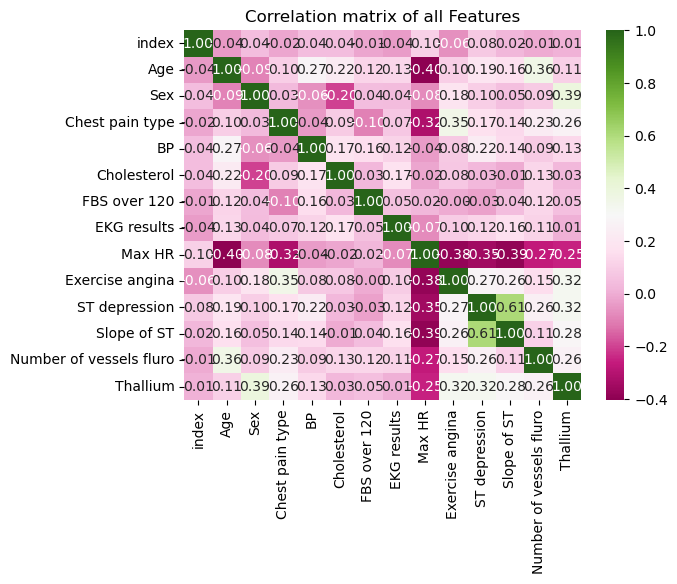

In [8]:
#Correlationmatrix
sns.heatmap(heart_data.corr(numeric_only=True), annot=True, fmt='.2f', cmap= "PiYG")
plt.title("Correlation matrix of all Features")

The correlation matrix illustrates the pairwise relationships between all features in the dataset. Most variables show weak to moderate correlations, indicating limited multicollinearity. Notable relationships include a moderate negative correlation between maximum heart rate and age, as well as stronger associations between ST depression and slope of ST, and between exercise-induced angina and maximum heart rate. These patterns suggest that while most features contribute independent information, certain cardiovascular measurements capture related physiological effects.

## 3. Preprocessing

Explain what kind of preprocessing, feature encoding you are applying

## 3.1 Cleaning the data

In [9]:
#drop the 'id' column
heart_data = heart_data.drop(columns=['index'])

## 3.2 Converting text labels to number (feature encoding)

In [10]:
y = heart_data.pop("Heart Disease")

In [11]:
# Target encoding for absence and presence of heart disease
encoder = preprocessing.LabelEncoder()
label_encoder = encoder.fit_transform(y)
print(label_encoder)

[1 0 1 0 0 0 1 1 1 1 0 0 0 1 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 1 1 1 1
 1 0 0 1 0 0 0 1 0 1 1 1 1 1 0 0 0 0 0 1 0 1 1 0 1 0 0 0 1 0 1 0 1 1 0 0 0
 0 1 0 0 0 0 1 1 1 0 0 0 0 0 0 1 0 1 1 1 1 1 0 1 0 0 0 1 0 1 1 1 0 1 1 0 1
 0 1 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 1 1 1 0 1 0 0 0 1 0 0 1 0 1 0 1 1 1 1
 1 0 0 0 0 0 0 0 1 0 0 1 1 1 0 1 0 0 0 0 0 1 0 1 1 0 0 1 1 1 1 0 0 1 1 0 0
 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 0 1 1 1 1 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 1 1
 0 1 0 0 1 1 0 0 1 1 0 1 0 1 0 1 0 0 1 0 0 1 0 1 1 0 1 1 1 0 1 0 0 0 0 1 1
 0 0 1 1 0 1 0 0 0 0 1]


## 3.3 Converting text labels to numbers (feature encoding)

In [12]:
# we change the percentage of train datasets
train_X, test_X, train_y, test_y = train_test_split(heart_data, label_encoder, train_size = 0.70, random_state = 1)

validation_X, test_X, validation_y, test_y = train_test_split(test_X, test_y, test_size = 0.5, random_state = 1)

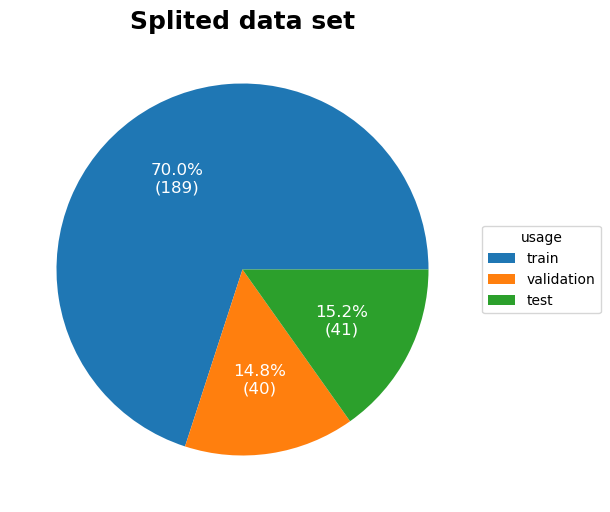

In [13]:
# count length
train_length = len(train_X)
validation_length = len(validation_X)
test_length = len(test_X)

# prepare for matplotlip
length = [train_length,validation_length,test_length]
label = ["train","validation","test"]

# plotting
fig, ax = plt.subplots(figsize=(6, 8), subplot_kw=dict(aspect="equal"))

def func(pct, allvals):
    absolute = int(np.round(pct/100.*np.sum(allvals)))
    return f"{pct:.1f}%\n({absolute:d})"


wedges, texts, autotexts = ax.pie(length, autopct=lambda pct: func(pct, length),
                                  textprops=dict(color="w"))

ax.legend(wedges, label,
          title= "usage",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.setp(autotexts, size=12)

ax.set_title("Splited data set", size = 18, weight = "bold")

plt.show()

In [14]:
#Testen ob balanced oder nicht
print("Allgemein:")
print(y.value_counts(), y.value_counts(normalize=True) * 100)


import pandas as pd

train_y = pd.Series(train_y)
validation_y = pd.Series(validation_y)
test_y = pd.Series(test_y)


print("\nTrain:")
print(train_y.value_counts(normalize=True)*100) 

print("\nValidation:")
print(validation_y.value_counts(normalize=True)*100)

print("\nTest:")
print(test_y.value_counts(normalize=True)*100)



Allgemein:
Heart Disease
Absence     150
Presence    120
Name: count, dtype: int64 Heart Disease
Absence     55.555556
Presence    44.444444
Name: proportion, dtype: float64

Train:
0    57.142857
1    42.857143
Name: proportion, dtype: float64

Validation:
1    50.0
0    50.0
Name: proportion, dtype: float64

Test:
0    53.658537
1    46.341463
Name: proportion, dtype: float64


The target variable shows a moderately balanced class distribution, with 55.6% of samples labeled as absence of heart disease and 44.4% as presence. This balance is largely preserved across the training and test sets, while the validation set is perfectly balanced, reducing the risk of class bias during model evaluation.

## Encoding

what needs to be encoded:
    Sex binary          category
    Chest pain type     unordered categories
    FBS over 120        binary
    EKG results         categories
    Exercise angina     binary
    Slope of ST         categories
    Thallium            categories

do not one hot enocde:
Age                         continuous
BP
Cholesterol
Max HR
ST depression
Number of vessels fluro     ordered count (0–3)




## 4. Modelling

### 4. 1 Logistic Regression
Logistic regression was chosen as an initial model due to its simplicity, interpretability, and suitability for binary classification tasks. It provides a strong baseline for evaluating model performance while allowing direct insight into feature contributions.




In [15]:
from sklearn.metrics import accuracy_score

#Skalieren
scaler = StandardScaler()

scaler.fit(train_X)
x_train_scaled = scaler.transform(train_X)

x_val_scaled = scaler.transform(validation_X)
x_test_scaled = scaler.transform(test_X)


#Train the model on training data
log_reg = LogisticRegression(max_iter = 1000, solver="liblinear", random_state=1)
log_reg.fit(x_train_scaled, train_y)

#Evaluate on training data
train_pred_log = log_reg.predict(x_train_scaled)
train_pred_prob = log_reg.predict_proba(x_train_scaled)[:,1]
print("Train Accuracy:", accuracy_score(train_y, train_pred_log))

#Evaluate on validation set
validation_pred_log = log_reg.predict(x_val_scaled)
print("Validation Accuracy:", accuracy_score(validation_y, validation_pred_log))

#Detailed classification report for validation set
print("\nValidation Classification Report:")
print(classification_report(validation_y, validation_pred_log))

Train Accuracy: 0.8571428571428571
Validation Accuracy: 0.825

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.90      0.84        20
           1       0.88      0.75      0.81        20

    accuracy                           0.82        40
   macro avg       0.83      0.82      0.82        40
weighted avg       0.83      0.82      0.82        40



The logistic regression model achieves a training accuracy of 85.7% and a validation accuracy of 82.5%, indicating good generalization and limited overfitting. The close alignment between training and validation performance suggests that the model effectively captures relevant patterns without relying excessively on noise in the training data.

The classification report further shows balanced performance across both classes. While the model attains higher recall for the absence of heart disease, it demonstrates higher precision for the presence class, reflecting a reasonable trade-off between sensitivity and specificity. The macro-averaged F1-score of 0.82 confirms consistent performance across classes, supporting the model’s reliability for heart disease classification.

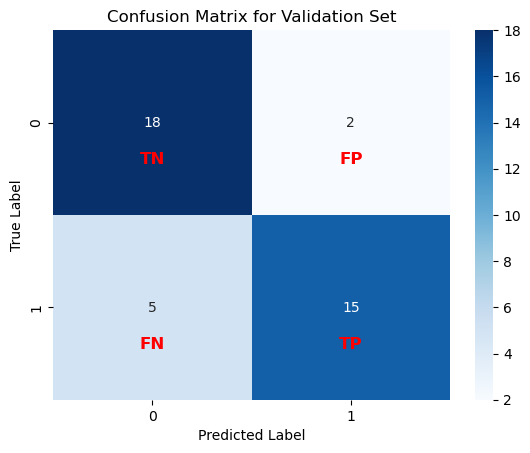

In [16]:
plt.Figure(figsize=(8,6))
sns.heatmap(confusion_matrix(validation_y, validation_pred_log), annot=True, fmt="d", cmap="Blues")

# Add TN, FP, FN, TP labels
labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        plt.text(j + 0.5, i + 0.7, labels[i][j], 
                ha='center', va='center', 
                fontsize=12, color='red', fontweight='bold')

plt.title("Confusion Matrix for Validation Set")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


The confusion matrix for the validation set indicates strong overall classification performance. Among patients without heart disease, 90% (18 out of 20) are correctly classified, while 10% are falsely predicted as having heart disease. For patients with heart disease, 75% (15 out of 20) are correctly identified, whereas 25% are misclassified as non-disease cases. This suggests that the model performs slightly better at recognizing non-disease cases and is more conservative in predicting heart disease, favoring precision over recall for the positive class.


Top 10 most Important Features:
                    feature  coefficients
11  Number of vessels fluro      0.965139
12                 Thallium      0.882188
2           Chest pain type      0.608439
1                       Sex      0.602404
7                    Max HR     -0.596119
9             ST depression      0.465792
6               EKG results      0.457659
8           Exercise angina      0.441498
3                        BP      0.441142
5              FBS over 120     -0.370911


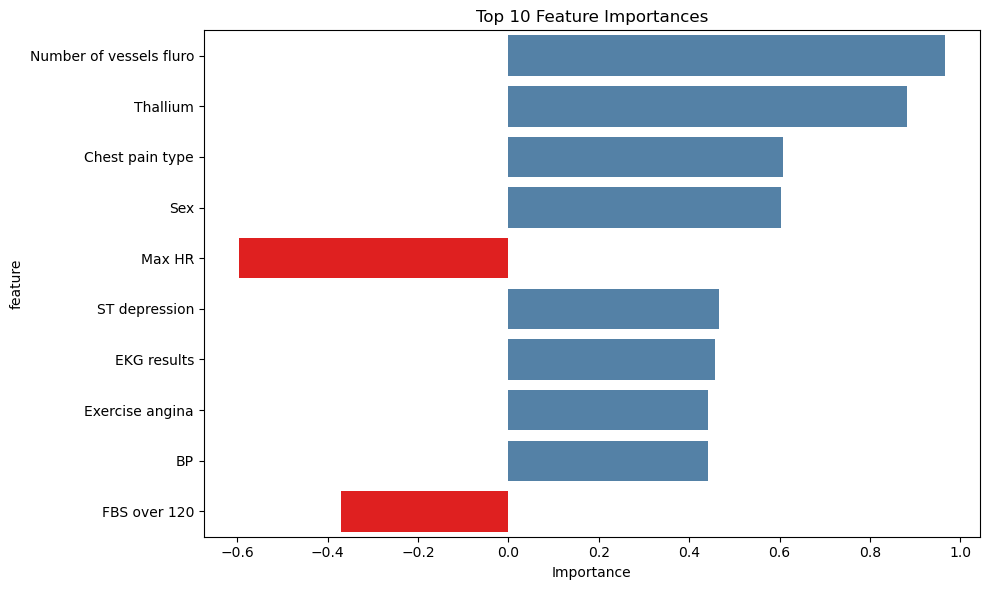

In [17]:
import numpy as np
import pandas as pd
# Feature Importance

# Ensure the feature names match the columns used for training
feature_names_log = train_X.columns

feature_import_log = pd.DataFrame({"feature": feature_names_log,
                               "coefficients": log_reg.coef_[0]}).sort_values("coefficients", key=abs, ascending=False)

top10 = feature_import_log.head(10)

print("\nTop 10 most Important Features:")
print(top10)

colors = ["red" if c < 0 else "steelblue" for c in top10["coefficients"]]

#Plot feature imporance
plt.figure(figsize=(10, 6))
sns.barplot(data=top10, x='coefficients', y='feature', orient='h', palette = colors)
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


The feature importance analysis based on logistic regression coefficients highlights several clinically relevant predictors. The number of vessels observed under fluoroscopy and thallium stress test results show the strongest positive association with heart disease presence. Chest pain type and sex also contribute substantially to the prediction. In contrast, maximum heart rate and fasting blood sugar over 120 exhibit negative coefficients, indicating an inverse relationship with the likelihood of heart disease. Overall, the results emphasize that both diagnostic test outcomes and physiological measurements play a key role in the model’s decision process.

#### 4.1.1 Final Model Evaluation on Test Set

In [19]:
#Testing
test_pred_log = log_reg.predict(test_X)
test_accuracy_log = accuracy_score(test_y, test_pred_log)

print("\nFINAL TEST SET RESULTS:")
print(f"Test Accuracy: {test_accuracy_log:.4f}")
print("\nTest Clssification Report:")
print(classification_report(test_y, test_pred_log))


FINAL TEST SET RESULTS:
Test Accuracy: 0.6585

Test Clssification Report:
              precision    recall  f1-score   support

           0       0.61      1.00      0.76        22
           1       1.00      0.26      0.42        19

    accuracy                           0.66        41
   macro avg       0.81      0.63      0.59        41
weighted avg       0.79      0.66      0.60        41



On the final test set, the model achieves an accuracy of 65.9%, indicating a noticeable drop in performance compared to the validation results. While the model perfectly identifies all non-heart-disease cases (recall = 1.00), it shows substantially reduced sensitivity for heart disease detection, with a recall of only 26% for the positive class. This imbalance suggests that the model is strongly biased toward predicting the absence of heart disease, resulting in a high number of false negatives.

Although precision for the heart disease class reaches 1.00, this reflects a conservative prediction strategy rather than robust detection capability. The low macro-averaged F1-score (0.59) further highlights the limited generalization of the model to unseen data, particularly for clinically relevant positive cases.

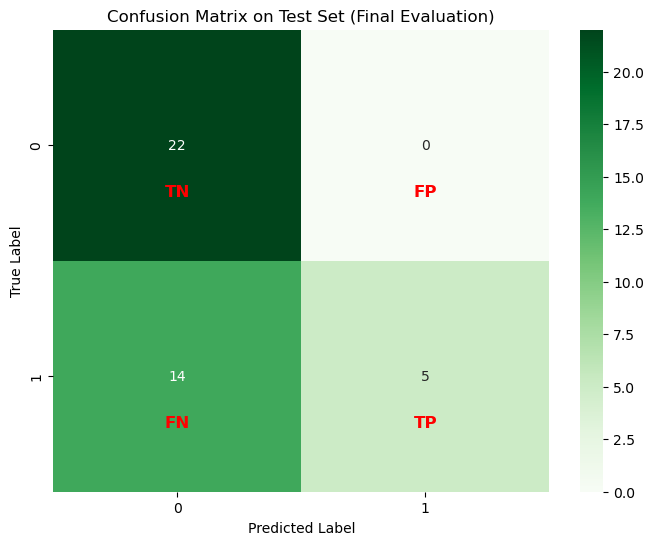

In [20]:
#Final confusion Matrix
log_test = confusion_matrix(test_y, test_pred_log)

plt.figure(figsize=(8, 6))
sns.heatmap(log_test, annot=True, fmt='d', cmap='Greens')
# Add TN, FP, FN, TP labels
labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        plt.text(j + 0.5, i + 0.7, labels[i][j], 
                ha='center', va='center', 
                fontsize=12, color='red', fontweight='bold')


plt.title('Confusion Matrix on Test Set (Final Evaluation)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

The confusion matrix confirms the previous results and shows that the model does not perform well on the test set. While the model correctly classifies 100% of non-heart-disease cases, it detects only 26% (5 out of 19) of heart disease cases on the test set, indicating limited sensitivity and a strong conservative prediction tendency.

##### ROC-Curve:
A ROC curve is used to evaluate how well a classification model distinguishes between two classes across different decision thresholds.

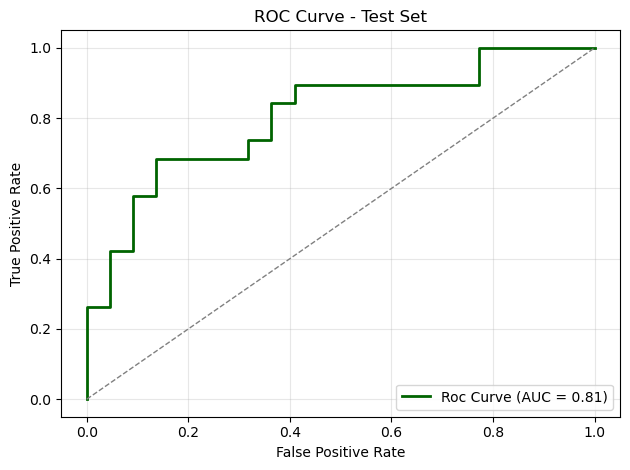

In [21]:
#Roc Curve
#predict probabilities for the positive class (Disease = 1)
test_probs_log = log_reg.predict_proba(test_X)[:,1]

#compute ROC curve
fpr_log, tpr_log, thresholds = roc_curve(test_y, test_probs_log)
roc_auc_log = auc(fpr_log, tpr_log)

#Plot ROC curve
plt.Figure(figsize=(8,6))
plt.plot(fpr_log,tpr_log, color ="darkgreen", lw = 2,
         label=f"Roc Curve (AUC = {roc_auc_log:.2f})")

plt.plot([0,1],[0,1], color = "gray", lw= 1, linestyle = "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Test Set")
plt.legend(loc = "lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

he ROC curve illustrates the model’s ability to separate heart disease and non-disease cases independently of a fixed classification threshold. An AUC value of 0.81 indicates good overall discriminative performance, even though threshold-based metrics such as accuracy and recall are limited on the test set.

### 4. 2 two sophisticated model approaches

number 1 random forest: captures feature interactions, non linear splits, robust on small datasets

numeber 2 Gradient Boosting or SVM (RBF)


#### Sources

Alshenawy, F. (2024). Using Machine Learning Algorithms to improve heart disease diagnoses. المجلة العلمية للدراسات والبحوث المالية والتجارية, 5(1), 417–442. https://doi.org/10.21608/cfdj.2024.324103

Detrano, R., Janosi, A., Steinbrunn, W., Pfisterer, M., Schmid, J.-J., Sandhu, S., Guppy, K. H., Lee, S., & Froelicher, V. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. The American Journal of Cardiology, 64(5), 304–310. https://doi.org/10.1016/0002-9149(89)90524-9

Kathleen, H., H., J., & J., G. (2016). Diagnosing Coronary Heart Disease using Ensemble Machine Learning. International Journal of Advanced Computer Science and Applications, 7(10). https://doi.org/10.14569/IJACSA.2016.071004

Karthick, K., Aruna, S. K., & Manikandan, R. (2022). Development and evaluation of the bootstrap resampling technique based statistical prediction model for Covid-19 real time data : A data driven approach. Journal of Interdisciplinary Mathematics, 25(3), 615–627. https://doi.org/10.1080/09720502.2021.2012890

Quah, J. L. J., Yap, S., Cheah, S. O., Ng, Y. Y., Goh, E. S., Doctor, N., Leong, B. S.-H., Tiah, L., Chia, M. Y. C., & Ong, M. E. H. (2014). Knowledge of Signs and Symptoms of Heart Attack and Stroke among Singapore Residents. BioMed Research International, 2014, 1–8. https://doi.org/10.1155/2014/572425

University of California, Irvine. (n.d.). Heart disease data set. UCI Machine Learning Repository. https://archive.ics.uci.edu/ml/datasets/Heart+Disease